In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
rng1 = np.random.default_rng(17)
rng2 = np.random.default_rng(42)
rngn = np.random.default_rng(123)
m = 100

# x1 is large (0 to 1000), x2 is small (0 to 5)
x1 = rng1.uniform(0, 1000, size=(m, 1))
x2 = rng2.uniform(0, 5, size=(m, 1))

# Design matrix X
X = np.hstack([x1, x2])

# Generate targets: y = 3*x1 + 10*x2 + noise
y = 3 * x1 + 10 * x2 + rngn.standard_normal(size=(m, 1)) * 50
print(X[0], y[0])

[845.0747928    3.86978024] [2524.4661133]


In [13]:
def compute_cost(X, y, W):
    return (1 / (2 * m)) * np.sum((X @ W - y) ** 2)

In [ ]:
# 3. Gradient Descent
def gradient_descent(X, y, lr=0.0000001, iterations=100):
    W = np.array(
        [[0.0], [0.0]]
    )  # Initialize weights at origin -- ok for linear regression
    history = [W.flatten()]
    print(
        f"{'iter':>4} | {'cost':>12} | {'w1':>10} {'dw1':>12} | {'w2':>10} {'dw2':>12}"
    )
    print("-" * 70)
    for _ in range(iterations):
        prediction = X @ W
        errors = prediction - y
        gradient = (1 / m) * (X.T @ errors)
        W = W - lr * gradient
        print(
            f"{_+1:4d} | {compute_cost(X, y, W):12.4f} | {W[0,0]:10.6f} {gradient[0,0]:12.6f} | {W[1,0]:10.6f} {gradient[1,0]:12.6f}"
        )
        history.append(W.flatten())

    return np.array(history)

In [15]:
history = gradient_descent(X, y, lr=1.5e-7, iterations=200)

iter |         cost |         w1          dw1 |         w2          dw2
----------------------------------------------------------------------
   1 | 1219019.3929 |   0.130851 -872336.958922 |   0.000519 -3461.326664
   2 | 1116705.0868 |   0.256084 -834892.124706 |   0.001016 -3313.871549
   3 | 1022985.8914 |   0.375943 -799054.599947 |   0.001492 -3172.745904
   4 |  937139.7580 |   0.490656 -764755.391319 |   0.001948 -3037.678040
   5 |  858505.2948 |   0.600445 -731928.467014 |   0.002384 -2908.407926
   6 |  786476.6714 |   0.705522 -700510.629624 |   0.002802 -2784.686697
   7 |  720498.9516 |   0.806088 -670441.394470 |   0.003202 -2666.276168
   8 |  660063.8175 |   0.902337 -641662.873163 |   0.003585 -2552.948379
   9 |  604705.6535 |   0.994455 -614119.662158 |   0.003951 -2444.485154
  10 |  553997.9590 |   1.082619 -587758.736093 |   0.004302 -2340.677683
  11 |  507550.0622 |   1.166999 -562529.345702 |   0.004639 -2241.326119
  12 |  465004.1106 |   1.247756 -538382.92

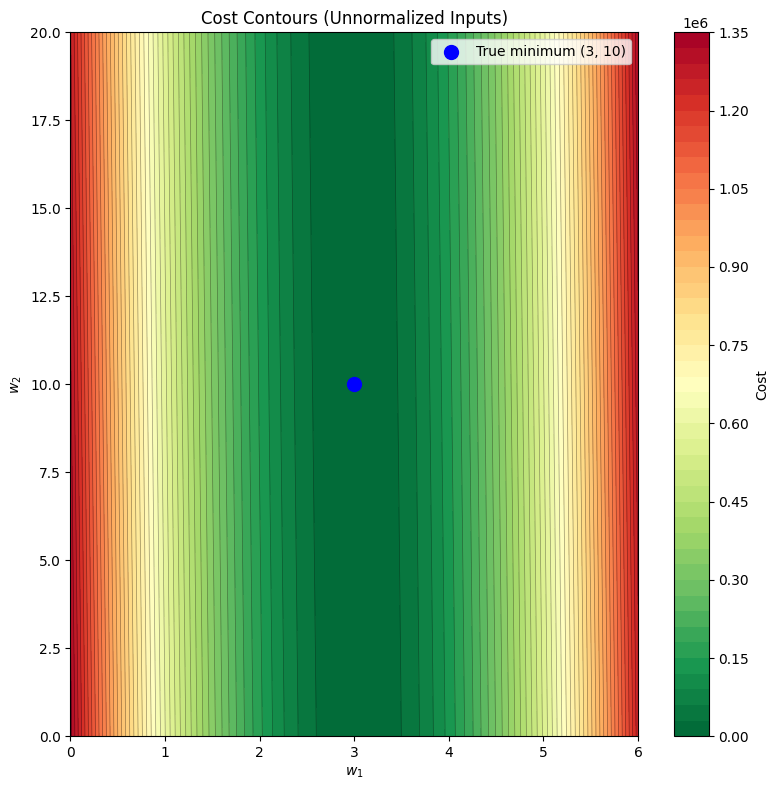

In [17]:
w1_range = np.linspace(0, 6, 200)  # true w1=3, so scan around it
w2_range = np.linspace(0, 20, 200)  # true w2=10, so scan around it
W1, W2 = np.meshgrid(w1_range, w2_range)
Cost = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W = np.array([[W1[i, j]], [W2[i, j]]])
        Cost[i, j] = compute_cost(X, y, W)

fig, ax = plt.subplots(figsize=(8, 8))
contour = ax.contourf(W1, W2, Cost, levels=50, cmap="RdYlGn_r")
ax.contour(W1, W2, Cost, levels=50, colors="black", linewidths=0.5, alpha=0.4)
fig.colorbar(contour, ax=ax, label="Cost")

# Mark the true minimum
ax.scatter([3], [10], color="blue", s=100, zorder=5, label="True minimum (3, 10)")
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_title("Cost Contours (Unnormalized Inputs)")
ax.legend()
plt.tight_layout()
plt.show()

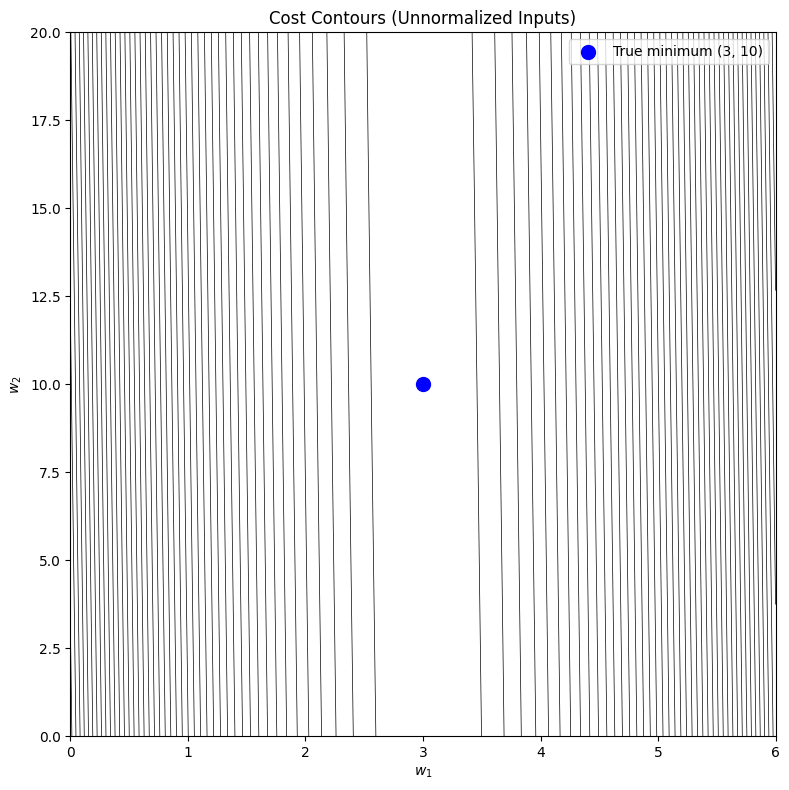

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

w1_range = np.linspace(0, 6, 200)
w2_range = np.linspace(0, 20, 200)
# w1_range = np.linspace(0, 6, 200)
# w2_range = np.linspace(-500, 500, 200)
W1, W2 = np.meshgrid(w1_range, w2_range)

Cost = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W = np.array([[W1[i, j]], [W2[i, j]]])
        Cost[i, j] = compute_cost(X, y, W)

# levels = np.linspace(np.min(Cost), np.percentile(Cost, 80), 50)
# ax.contour(W1, W2, Cost, levels=levels, colors="black", linewidths=0.5)
ax.contour(W1, W2, Cost, levels=50, colors="black", linewidths=0.5)
ax.scatter([3], [10], color="blue", s=100, zorder=5, label="True minimum (3, 10)")
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_title("Cost Contours (Unnormalized Inputs)")
ax.legend()
plt.tight_layout()
plt.show()

iter |         cost |         w1          dw1 |         w2          dw2
----------------------------------------------------------------------
   1 | 1219019.3929 |   0.130851 -872336.958922 |   0.000519 -3461.326664
   2 | 1116705.0868 |   0.256084 -834892.124706 |   0.001016 -3313.871549
   3 | 1022985.8914 |   0.375943 -799054.599947 |   0.001492 -3172.745904
   4 |  937139.7580 |   0.490656 -764755.391319 |   0.001948 -3037.678040
   5 |  858505.2948 |   0.600445 -731928.467014 |   0.002384 -2908.407926
   6 |  786476.6714 |   0.705522 -700510.629624 |   0.002802 -2784.686697
   7 |  720498.9516 |   0.806088 -670441.394470 |   0.003202 -2666.276168
   8 |  660063.8175 |   0.902337 -641662.873163 |   0.003585 -2552.948379
   9 |  604705.6535 |   0.994455 -614119.662158 |   0.003951 -2444.485154
  10 |  553997.9590 |   1.082619 -587758.736093 |   0.004302 -2340.677683
  11 |  507550.0622 |   1.166999 -562529.345702 |   0.004639 -2241.326119
  12 |  465004.1106 |   1.247756 -538382.92

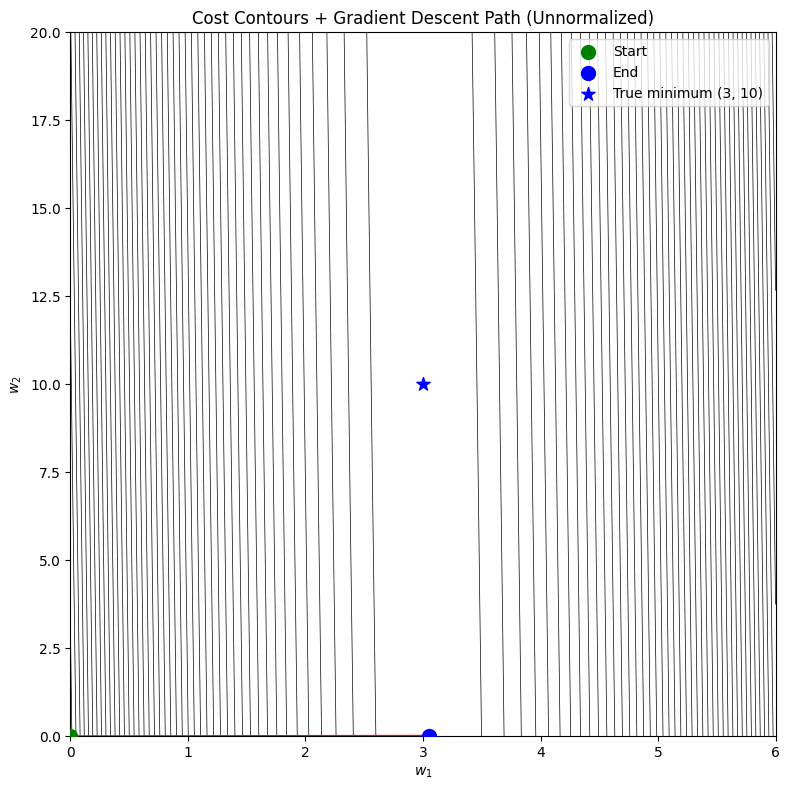

In [32]:
fig, ax = plt.subplots(figsize=(8, 8))

# w1_range = np.linspace(0, 6, 200)
# w2_range = np.linspace(-500, 500, 200)
w1_range = np.linspace(0, 6, 200)
w2_range = np.linspace(0, 20, 200)
W1, W2 = np.meshgrid(w1_range, w2_range)

Cost = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W = np.array([[W1[i, j]], [W2[i, j]]])
        Cost[i, j] = compute_cost(X, y, W)

ax.contour(W1, W2, Cost, levels=50, colors="black", linewidths=0.5)

# Overlay gradient descent path
history = gradient_descent(X, y, lr=1.5e-7, iterations=2000)
ax.plot(history[:, 0], history[:, 1], color="red", linewidth=1.5, zorder=5)
ax.scatter(history[0, 0], history[0, 1], color="green", s=100, zorder=6, label="Start")
ax.scatter(history[-1, 0], history[-1, 1], color="blue", s=100, zorder=6, label="End")

ax.scatter(
    [3], [10], color="blue", s=100, marker="*", zorder=7, label="True minimum (3, 10)"
)
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_title("Cost Contours + Gradient Descent Path (Unnormalized)")
# ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
X_shifted = X - np.mean(X, axis=0)
X_norm = X_shifted / np.std(X_shifted, axis=0)
y_mean = np.mean(y)
y_std = np.std(y)
y_norm = (y - y_mean) / y_std
history = gradient_descent(X_norm, y_norm, lr=0.01, iterations=200)

iter |         cost |         w1          dw1 |         w2          dw2
----------------------------------------------------------------------
   1 |       0.4901 |   0.009984    -0.998371 |  -0.000087     0.008682
   2 |       0.4804 |   0.019868    -0.988386 |  -0.000171     0.008401
   3 |       0.4708 |   0.029653    -0.978500 |  -0.000252     0.008125
   4 |       0.4615 |   0.039340    -0.968714 |  -0.000331     0.007853
   5 |       0.4523 |   0.048930    -0.959025 |  -0.000406     0.007586
   6 |       0.4434 |   0.058424    -0.949433 |  -0.000480     0.007323
   7 |       0.4346 |   0.067824    -0.939937 |  -0.000550     0.007065
   8 |       0.4260 |   0.077129    -0.930537 |  -0.000618     0.006811
   9 |       0.4175 |   0.086341    -0.921230 |  -0.000684     0.006562
  10 |       0.4092 |   0.095461    -0.912016 |  -0.000747     0.006317
  11 |       0.4011 |   0.104490    -0.902895 |  -0.000808     0.006076
  12 |       0.3932 |   0.113429    -0.893865 |  -0.000866     0.

iter |         cost |         w1          dw1 |         w2          dw2
----------------------------------------------------------------------
   1 | 1219019.3929 |   0.130851 -872336.958922 |   0.000519 -3461.326664
   2 | 1116705.0868 |   0.256084 -834892.124706 |   0.001016 -3313.871549
   3 | 1022985.8914 |   0.375943 -799054.599947 |   0.001492 -3172.745904
   4 |  937139.7580 |   0.490656 -764755.391319 |   0.001948 -3037.678040
   5 |  858505.2948 |   0.600445 -731928.467014 |   0.002384 -2908.407926
   6 |  786476.6714 |   0.705522 -700510.629624 |   0.002802 -2784.686697
   7 |  720498.9516 |   0.806088 -670441.394470 |   0.003202 -2666.276168
   8 |  660063.8175 |   0.902337 -641662.873163 |   0.003585 -2552.948379
   9 |  604705.6535 |   0.994455 -614119.662158 |   0.003951 -2444.485154
  10 |  553997.9590 |   1.082619 -587758.736093 |   0.004302 -2340.677683
  11 |  507550.0622 |   1.166999 -562529.345702 |   0.004639 -2241.326119
  12 |  465004.1106 |   1.247756 -538382.92

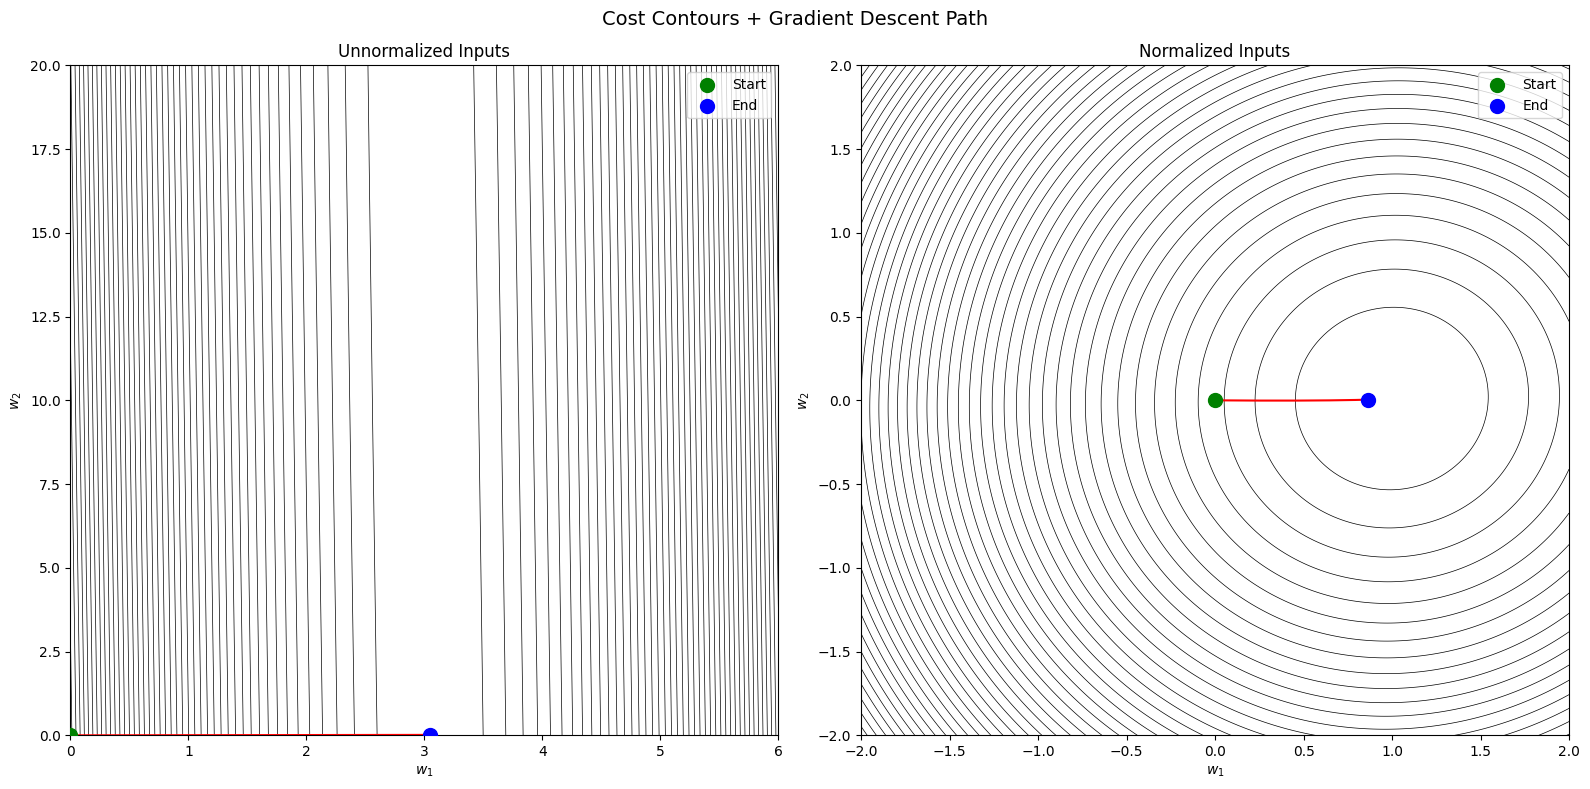

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Unnormalized ──────────────────────────────────────────────
w1_range_un = np.linspace(0, 6, 200)
w2_range_un = np.linspace(0, 20, 200)
W1_un, W2_un = np.meshgrid(w1_range_un, w2_range_un)

Cost_un = np.zeros_like(W1_un)
for i in range(W1_un.shape[0]):
    for j in range(W1_un.shape[1]):
        W = np.array([[W1_un[i, j]], [W2_un[i, j]]])
        Cost_un[i, j] = compute_cost(X, y, W)

axes[0].contour(W1_un, W2_un, Cost_un, levels=50, colors="black", linewidths=0.5)
history_un = gradient_descent(X, y, lr=1.5e-7, iterations=200)
axes[0].plot(history_un[:, 0], history_un[:, 1], color="red", linewidth=1.5, zorder=5)
axes[0].scatter(
    history_un[0, 0], history_un[0, 1], color="green", s=100, zorder=6, label="Start"
)
axes[0].scatter(
    history_un[-1, 0], history_un[-1, 1], color="blue", s=100, zorder=6, label="End"
)
axes[0].set_xlabel("$w_1$")
axes[0].set_ylabel("$w_2$")
axes[0].set_title("Unnormalized Inputs")
axes[0].legend()

# ── Normalized ────────────────────────────────────────────────
y_mean = np.mean(y)
y_std = np.std(y)
y_norm = (y - y_mean) / y_std

X_shifted = X - np.mean(X, axis=0)
X_norm = X_shifted / np.std(X_shifted, axis=0)

w1_range_n = np.linspace(-2, 2, 200)
w2_range_n = np.linspace(-2, 2, 200)
W1_n, W2_n = np.meshgrid(w1_range_n, w2_range_n)

Cost_n = np.zeros_like(W1_n)
for i in range(W1_n.shape[0]):
    for j in range(W1_n.shape[1]):
        W = np.array([[W1_n[i, j]], [W2_n[i, j]]])
        Cost_n[i, j] = compute_cost(X_norm, y_norm, W)

axes[1].contour(W1_n, W2_n, Cost_n, levels=50, colors="black", linewidths=0.5)
history_n = gradient_descent(X_norm, y_norm, lr=0.01, iterations=200)
axes[1].plot(history_n[:, 0], history_n[:, 1], color="red", linewidth=1.5, zorder=5)
axes[1].scatter(
    history_n[0, 0], history_n[0, 1], color="green", s=100, zorder=6, label="Start"
)
axes[1].scatter(
    history_n[-1, 0], history_n[-1, 1], color="blue", s=100, zorder=6, label="End"
)
axes[1].set_xlabel("$w_1$")
axes[1].set_ylabel("$w_2$")
axes[1].set_title("Normalized Inputs")
axes[1].legend()

fig.suptitle("Cost Contours + Gradient Descent Path", fontsize=14)
plt.tight_layout()
plt.show()